In [1]:
import pandas as pd, numpy as np
df = pd.read_csv('hr.csv')
df.sample(5)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
5988,0.72,0.99,4,227,3,0,0,0,hr,high
3952,0.69,0.81,3,214,2,0,0,0,IT,low
10335,0.14,0.43,2,238,3,0,0,0,hr,low
14656,0.09,0.94,6,283,5,0,1,0,IT,low
5097,0.53,0.83,4,246,3,0,0,0,IT,high


In [2]:
from ydata_profiling import ProfileReport
hr = ProfileReport(df)
hr.to_file(output_file = 'hr.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 15.89it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

### Detecting Missing Values

In [3]:
df.isnull().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
sales                    0
salary                   0
dtype: int64

- no missing values in the data

### Checking for any Duplicate Samples

In [4]:
df.duplicated().any()

np.True_

In [5]:
df = df.drop_duplicates().copy()

In [6]:
df.duplicated().any()

np.False_

### Checking for Outliers

In [7]:
%matplotlib inline
import matplotlib.pyplot as plt, seaborn as sns

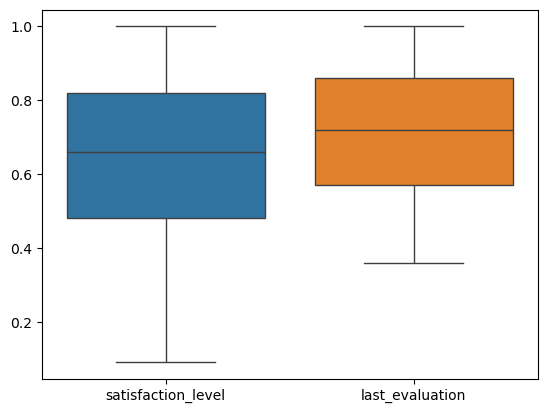

In [8]:
sns.boxplot(df[['satisfaction_level', 'last_evaluation']])
plt.show()

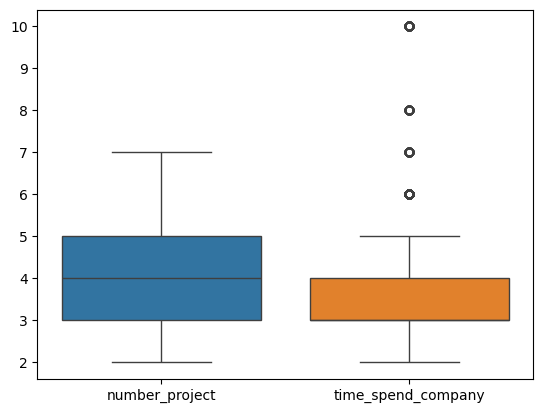

In [9]:
sns.boxplot(df[['number_project', 'time_spend_company']])
plt.show()

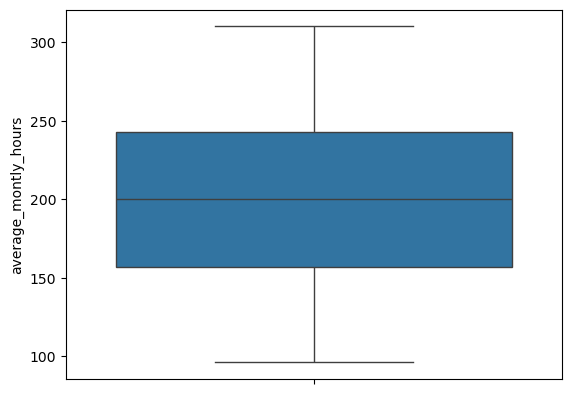

In [10]:
sns.boxplot(df['average_montly_hours'])
plt.show()

- there are some outliers in `time_spend_company` column

### Handling Outliers

In [11]:
df['time_spend_company'].unique()

array([ 3,  6,  4,  5,  2,  8, 10,  7])

- the outliers present here are not actually an outlier but senior employees so we need to keep them

In [12]:
df.groupby('time_spend_company')['left'].mean()

time_spend_company
2     0.010653
3     0.168401
4     0.246883
5     0.453861
6     0.201107
7     0.000000
8     0.000000
10    0.000000
Name: left, dtype: float64

In [13]:
df['time_spend_company'].value_counts()

time_spend_company
3     5190
2     2910
4     2005
5     1062
6      542
10     107
7       94
8       81
Name: count, dtype: int64

- 5 years time spent in company has highest risk of leaving
- more than 7 years time spent in company has 0% risk of leaving (can be due to small sample size) **loyal senior employees**

In [14]:
df['5year_experience'] = (df['time_spend_company']==5).astype(int)
df['senior_employee'] = (df['time_spend_company'] >= 7).astype(int)

In [15]:
df.sample(5)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary,5year_experience,senior_employee
4094,0.30,0.80,6,250,3,0,0,0,support,low,0,0
10626,0.16,0.54,5,206,5,0,0,0,sales,medium,1,0
5374,0.58,0.62,5,184,3,0,0,0,hr,low,0,0
414,0.91,0.97,5,233,5,0,1,0,hr,medium,1,0
10801,0.90,0.77,4,273,2,0,0,0,technical,low,0,0


### Working on `satisfaction_level`

In [16]:
df['satisfaction_level'].unique()

array([0.38, 0.8 , 0.11, 0.72, 0.37, 0.41, 0.1 , 0.92, 0.89, 0.42, 0.45,
       0.84, 0.36, 0.78, 0.76, 0.09, 0.46, 0.4 , 0.82, 0.87, 0.57, 0.43,
       0.13, 0.44, 0.39, 0.85, 0.81, 0.9 , 0.74, 0.79, 0.17, 0.24, 0.91,
       0.71, 0.86, 0.14, 0.75, 0.7 , 0.31, 0.73, 0.83, 0.32, 0.54, 0.27,
       0.77, 0.88, 0.48, 0.19, 0.6 , 0.12, 0.61, 0.33, 0.56, 0.47, 0.28,
       0.55, 0.53, 0.59, 0.66, 0.25, 0.34, 0.58, 0.51, 0.35, 0.64, 0.5 ,
       0.23, 0.15, 0.49, 0.3 , 0.63, 0.21, 0.62, 0.29, 0.2 , 0.16, 0.65,
       0.68, 0.67, 0.22, 0.26, 0.99, 0.98, 1.  , 0.52, 0.93, 0.97, 0.69,
       0.94, 0.96, 0.18, 0.95])

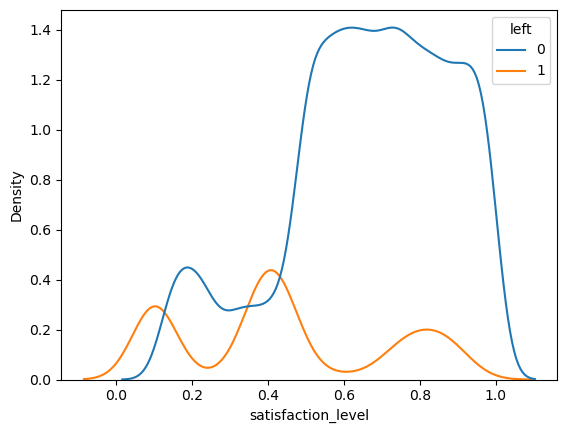

In [17]:
sns.kdeplot(data=df, x='satisfaction_level', hue='left')
plt.show()

In [18]:
temp = df.groupby('satisfaction_level')['left'].mean()

In [19]:
print(temp[temp==1])

satisfaction_level
0.09    1.0
0.10    1.0
0.11    1.0
Name: left, dtype: float64


In [20]:
print(temp[temp==0])

satisfaction_level
0.18    0.0
0.52    0.0
0.69    0.0
0.93    0.0
0.94    0.0
0.95    0.0
0.96    0.0
0.97    0.0
0.98    0.0
0.99    0.0
1.00    0.0
Name: left, dtype: float64


- below satisfaction level 0.11 everyone left
- above satisfaction level 0.93 no one left

In [21]:
df['very_low_sat'] = (df['satisfaction_level'] <= 0.11).astype(int)
df['very_high_sat'] = (df['satisfaction_level'] >= 0.93).astype(int)

In [22]:
df.sample(5)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary,5year_experience,senior_employee,very_low_sat,very_high_sat
10565,0.85,0.64,4,188,3,0,0,0,hr,low,0,0,0,0
5586,0.81,0.99,2,156,5,0,0,0,sales,medium,1,0,0,0
9020,0.69,0.80,3,177,4,0,0,0,sales,low,0,0,0,0
4021,1.00,0.49,3,106,4,0,0,0,support,low,0,0,0,1
7014,0.21,0.62,4,247,3,1,0,0,product_mng,low,0,0,0,0


### Working on `last_evaluation`

In [23]:
df['last_evaluation'].unique()

array([0.53, 0.86, 0.88, 0.87, 0.52, 0.5 , 0.77, 0.85, 1.  , 0.54, 0.81,
       0.92, 0.55, 0.56, 0.47, 0.99, 0.51, 0.89, 0.83, 0.95, 0.57, 0.49,
       0.46, 0.62, 0.94, 0.48, 0.8 , 0.74, 0.7 , 0.78, 0.91, 0.93, 0.98,
       0.97, 0.79, 0.59, 0.84, 0.45, 0.96, 0.68, 0.82, 0.9 , 0.71, 0.6 ,
       0.65, 0.58, 0.72, 0.67, 0.75, 0.73, 0.63, 0.61, 0.76, 0.66, 0.69,
       0.37, 0.64, 0.39, 0.41, 0.43, 0.44, 0.36, 0.38, 0.4 , 0.42])

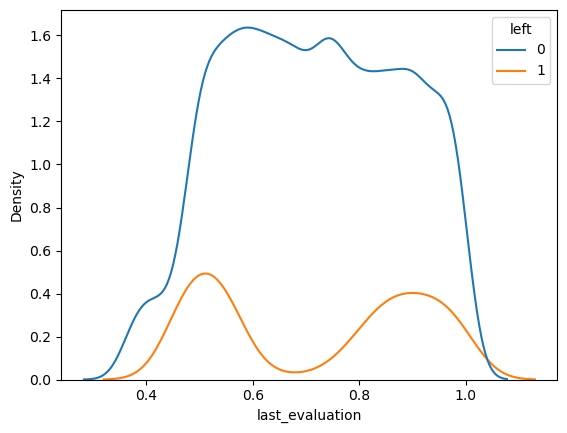

In [24]:
sns.kdeplot(data=df, x='last_evaluation', hue='left')
plt.show()

In [25]:
temp = df.groupby('last_evaluation')['left'].mean()

In [26]:
print(temp[temp==0])

last_evaluation
0.36    0.0
0.37    0.0
0.38    0.0
0.39    0.0
0.40    0.0
0.41    0.0
0.42    0.0
0.43    0.0
0.44    0.0
0.64    0.0
0.69    0.0
Name: left, dtype: float64


In [27]:
print(temp[temp>=0.9])

Series([], Name: left, dtype: float64)


- does not have any clean boundary for leaving

### Working with `number_project`

In [28]:
df['number_project'].unique()

array([2, 5, 7, 6, 4, 3])

In [29]:
df.groupby('number_project')['left'].mean()

number_project
2    0.541719
3    0.010795
4    0.064315
5    0.153605
6    0.449153
7    1.000000
Name: left, dtype: float64

- for number of project 2 and 6 leaving rate is high
- for number of project 7 everyone left

In [30]:
df['low_project_load'] = (df['number_project']<=2).astype(int)
df['high_project_load'] = (df['number_project']>=6).astype(int)
df['extreme_project_load'] = (df['number_project']>=7).astype(int)

In [31]:
df.sample(5)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary,5year_experience,senior_employee,very_low_sat,very_high_sat,low_project_load,high_project_load,extreme_project_load
1477,0.38,0.46,2,155,3,0,1,0,sales,low,0,0,0,0,1,0,0
7218,0.55,0.65,5,138,2,0,0,0,technical,medium,0,0,0,0,0,0,0
7001,0.63,0.81,3,215,3,0,0,0,support,medium,0,0,0,0,0,0,0
645,0.40,0.54,2,141,3,0,1,0,technical,medium,0,0,0,0,1,0,0
11273,0.51,0.55,2,102,7,0,0,1,management,medium,0,1,0,0,1,0,0


### Working with `average_monthly_hours`

In [32]:
df = df.rename(columns={'average_montly_hours':'average_monthly_hours'})

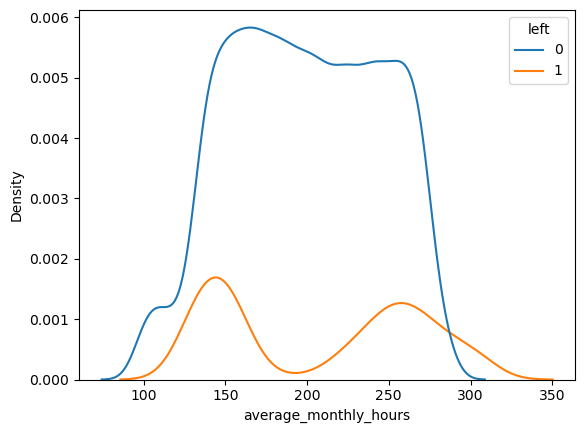

In [33]:
sns.kdeplot(data=df, x='average_monthly_hours', hue='left')
plt.show()

In [34]:
df['average_monthly_hours'].unique()

array([157, 262, 272, 223, 159, 153, 247, 259, 224, 142, 135, 305, 234,
       148, 137, 143, 160, 255, 282, 147, 304, 139, 158, 242, 239, 128,
       132, 294, 134, 145, 140, 246, 126, 306, 152, 269, 127, 281, 276,
       182, 273, 307, 309, 225, 226, 308, 244, 286, 161, 264, 277, 275,
       149, 295, 151, 249, 291, 232, 130, 129, 155, 265, 279, 284, 221,
       154, 150, 267, 257, 177, 144, 289, 258, 263, 251, 133, 216, 300,
       138, 260, 183, 250, 292, 283, 245, 256, 278, 240, 136, 301, 243,
       296, 274, 164, 146, 261, 285, 141, 297, 156, 287, 219, 254, 228,
       131, 252, 236, 270, 298, 192, 248, 266, 238, 229, 233, 268, 231,
       253, 302, 271, 290, 235, 293, 241, 218, 199, 180, 195, 237, 227,
       172, 206, 181, 217, 310, 214, 198, 211, 222, 213, 202, 184, 204,
       288, 220, 299, 303, 212, 196, 179, 205, 230, 203, 280, 169, 188,
       178, 175, 166, 163, 168, 165, 189, 162, 215, 193, 176, 191, 174,
       201, 208, 171, 111, 104, 106, 100, 194, 209, 185, 200, 20

In [35]:
temp = df.groupby('average_monthly_hours')['left'].mean()

In [36]:
print(temp[temp==0])

average_monthly_hours
96     0.0
97     0.0
98     0.0
99     0.0
100    0.0
101    0.0
102    0.0
103    0.0
104    0.0
105    0.0
106    0.0
107    0.0
108    0.0
109    0.0
110    0.0
111    0.0
112    0.0
113    0.0
114    0.0
115    0.0
116    0.0
117    0.0
118    0.0
119    0.0
120    0.0
121    0.0
122    0.0
123    0.0
124    0.0
125    0.0
167    0.0
170    0.0
171    0.0
173    0.0
174    0.0
176    0.0
185    0.0
186    0.0
187    0.0
190    0.0
191    0.0
193    0.0
194    0.0
197    0.0
200    0.0
201    0.0
207    0.0
208    0.0
209    0.0
210    0.0
215    0.0
Name: left, dtype: float64


In [37]:
print(temp[temp==1])

average_monthly_hours
288    1.0
289    1.0
290    1.0
291    1.0
292    1.0
293    1.0
294    1.0
295    1.0
296    1.0
297    1.0
298    1.0
299    1.0
300    1.0
301    1.0
302    1.0
303    1.0
304    1.0
305    1.0
306    1.0
307    1.0
308    1.0
309    1.0
310    1.0
Name: left, dtype: float64


- employee with average monthly hours more than 288 all left
- upto monthly work hours 125 no one left then varied

In [38]:
df['overworked'] = (df['average_monthly_hours']>=288).astype(int)
df['underworked'] = (df['average_monthly_hours']<=125).astype(int)

In [39]:
df.sample(5)

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary,5year_experience,senior_employee,very_low_sat,very_high_sat,low_project_load,high_project_load,extreme_project_load,overworked,underworked
11021,0.56,0.92,4,224,3,0,0,0,sales,medium,0,0,0,0,0,0,0,0,0
16,0.45,0.47,2,160,3,0,1,0,sales,low,0,0,0,0,1,0,0,0,0
1949,0.91,0.99,5,254,5,0,1,0,technical,medium,1,0,0,0,0,0,0,0,0
7844,0.24,0.65,6,210,5,0,0,0,management,high,1,0,0,0,0,1,0,0,0
5620,0.50,0.85,4,150,2,0,0,0,support,high,0,0,0,0,0,0,0,0,0


In [40]:
df['hours_per_project'] = df['average_monthly_hours'] / df['number_project']

- already worked on `time_spend_company`
- `Work_accident` and `promotion_last_5years` are binary columns

In [41]:
df.groupby('Work_accident')['left'].mean()

Work_accident
0    0.185978
1    0.056757
Name: left, dtype: float64

In [42]:
df.groupby('promotion_last_5years')['left'].mean()

promotion_last_5years
0    0.168222
1    0.039409
Name: left, dtype: float64

In [43]:
df.groupby('sales')['left'].mean()

sales
IT             0.161885
RandD          0.122478
accounting     0.175523
hr             0.188020
management     0.119266
marketing      0.166419
product_mng    0.160350
sales          0.169805
support        0.171334
technical      0.173797
Name: left, dtype: float64

In [44]:
df.sample(10)

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary,5year_experience,senior_employee,very_low_sat,very_high_sat,low_project_load,high_project_load,extreme_project_load,overworked,underworked,hours_per_project
11419,0.64,0.66,5,157,2,0,0,0,product_mng,low,0,0,0,0,0,0,0,0,0,31.400000
11406,0.82,0.71,2,209,5,0,0,1,marketing,medium,1,0,0,0,1,0,0,0,0,104.500000
1465,0.45,0.47,2,146,3,0,1,0,sales,medium,0,0,0,0,1,0,0,0,0,73.000000
9162,0.52,0.59,3,164,3,0,0,0,technical,medium,0,0,0,0,0,0,0,0,0,54.666667
3592,0.75,0.59,5,206,2,0,0,0,marketing,low,0,0,0,0,0,0,0,0,0,41.200000
129,0.37,0.45,2,151,3,0,1,0,support,low,0,0,0,0,1,0,0,0,0,75.500000
2264,0.47,0.64,3,192,3,0,0,0,support,low,0,0,0,0,0,0,0,0,0,64.000000
7371,0.21,0.85,6,221,5,0,0,0,technical,medium,1,0,0,0,0,1,0,0,0,36.833333
8864,0.81,0.56,3,142,3,0,0,0,sales,low,0,0,0,0,0,0,0,0,0,47.333333
5232,0.32,0.40,6,162,5,0,0,0,technical,low,1,0,0,0,0,1,0,0,0,27.000000


### Encoding input features

In [45]:
from sklearn.preprocessing import OrdinalEncoder
oe = OrdinalEncoder(categories=[['low', 'medium', 'high']])
df[['salary']] = oe.fit_transform(df[['salary']])

In [46]:
df.sample(5)

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary,5year_experience,senior_employee,very_low_sat,very_high_sat,low_project_load,high_project_load,extreme_project_load,overworked,underworked,hours_per_project
5768,0.93,0.68,2,150,3,0,0,0,technical,0.0,0,0,0,1,1,0,0,0,0,75.0
10781,0.89,0.88,5,241,2,1,0,0,sales,1.0,0,0,0,0,0,0,0,0,0,48.2
6488,0.53,0.73,5,174,3,0,0,0,accounting,2.0,0,0,0,0,0,0,0,0,0,34.8
4999,0.64,0.97,4,268,2,0,0,0,technical,0.0,0,0,0,0,0,0,0,0,0,67.0
1842,0.38,0.51,2,159,3,0,1,0,sales,0.0,0,0,0,0,1,0,0,0,0,79.5


### Scaling Data

In [47]:
from sklearn.preprocessing import StandardScaler, RobustScaler
ss = StandardScaler()
rs = RobustScaler()

In [48]:
numeric_columns = ['satisfaction_level', 'last_evaluation', 'number_project', 'average_monthly_hours', 'hours_per_project']

In [49]:
df[numeric_columns] = ss.fit_transform(df[numeric_columns])
df.sample(5)

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary,5year_experience,senior_employee,very_low_sat,very_high_sat,low_project_load,high_project_load,extreme_project_load,overworked,underworked,hours_per_project
7778,1.079988,-0.930775,0.169489,0.831726,5,0,0,0,IT,0.0,1,0,0,0,0,0,0,0,0,0.180830
2233,0.291803,1.029595,1.888899,0.277604,2,0,0,0,sales,0.0,0,0,0,0,0,1,0,0,0,-1.091094
6954,-0.164515,-0.990180,0.169489,-1.282145,2,0,0,0,marketing,2.0,0,0,0,0,0,0,0,0,0,-1.151457
81,-1.035668,-1.346611,-1.549921,-1.015346,3,0,1,0,technical,0.0,0,0,0,0,1,0,0,0,0,0.969853
3942,1.079988,1.089000,0.169489,-0.974300,3,0,0,0,support,0.0,0,0,0,0,0,0,0,0,0,-0.957434


In [50]:
df[['time_spend_company']] = rs.fit_transform(df[['time_spend_company']])
df.sample(5)

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary,5year_experience,senior_employee,very_low_sat,very_high_sat,low_project_load,high_project_load,extreme_project_load,overworked,underworked,hours_per_project
2593,-0.247482,1.089000,-0.690216,1.139571,1.0,0,0,0,RandD,0.0,0,0,0,0,0,0,0,0,0,1.478623
1548,1.121472,1.623647,0.169489,1.201140,3.0,0,1,0,sales,1.0,0,0,0,0,0,0,0,0,0,0.413656
6422,0.582187,-0.752559,0.169489,-1.241099,0.0,0,0,0,sales,1.0,0,0,0,0,0,0,0,0,0,-1.125587
4904,0.291803,0.791975,0.169489,0.647018,0.0,0,0,0,sales,1.0,0,0,0,0,0,0,0,0,0,0.064416
5273,-2.072754,-0.514939,1.888899,0.380219,3.0,0,0,0,marketing,0.0,0,0,0,0,0,1,0,0,0,-1.047978


In [51]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output=False)
encoded = ohe.fit_transform(df[['sales']])
encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(['sales']), index=df.index)
df = df.drop('sales', axis=1)
df = pd.concat([df, encoded_df], axis=1)

In [52]:
df.sample(20)

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,Work_accident,left,promotion_last_5years,salary,5year_experience,...,sales_IT,sales_RandD,sales_accounting,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical
8163,-0.247482,-0.158508,-0.690216,-0.953777,-1.0,0,0,0,0.0,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
235,0.831088,0.791975,0.169489,1.119048,2.0,0,1,0,0.0,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
7453,1.328889,0.257328,0.169489,0.400742,0.0,0,0,0,1.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4642,-0.164515,0.613759,-1.549921,0.667541,-1.0,0,0,0,1.0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6249,-0.123032,0.376139,1.888899,0.216035,1.0,1,0,0,1.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1628,-0.952701,-1.049585,-1.549921,-0.912731,0.0,0,1,0,1.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
6498,-0.123032,0.197923,1.029194,0.667541,0.0,1,0,0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
10467,-0.164515,-1.168396,1.888899,-0.214948,1.0,0,0,0,1.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
11939,1.204439,-0.099103,-0.690216,-1.466852,0.0,0,0,1,2.0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
9729,-0.662317,-1.821852,-1.549921,-1.241099,0.0,0,0,0,1.0,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [54]:
df.to_csv('hr_processed.csv', index=False)